# 08 — OE Engine Comparison: `dask_engine` vs `optimistix_engine`

Side-by-side comparison of the two inversion back-ends on the same
Sentinel-2 Wadden Sea scene used in NB07b.

| | `dask_engine` | `optimistix_engine` |
|---|---|---|
| Solver | Hand-written Gauss-Newton | `optx.GaussNewton` (default); `optx.LevenbergMarquardt` via `use_lm=True` |
| Iteration loop | Python `for` → **unrolled** at compile time | `lax.while_loop` → **not unrolled** |
| Stopping | Fixed `n_iter` | Convergence-based (`rtol`, `atol`) + `max_steps` cap |
| LM damping | Static scalar | Optional via `use_lm=True` |
| Parallelism | Dask tile dispatch | Single `jax.vmap` over all pixels |

Both back-ends use the same `InversionSetup` from `oe_engine.build_inversion()`
and return the same `OEResult` fields.

**What this notebook measures:**
1. First-run time (JIT compilation + execution)
2. Second-run time (compiled, execution only)
3. Numerical agreement of `x_hat`, `chi2`, `sigma`, `A_diag`

> **Note (S2 benchmark, GPU):** `dask_engine` wins decisively on hot-run execution for this
> problem size (2 params, 8 bands, ~120 k pixels): ~5.7 s vs ~27 s for the `while_loop`-based
> paths.  The unrolled GN loop compiles to a fixed-size XLA program that XLA can aggressively
> fuse and schedule; `lax.while_loop` produces a dynamic graph that cannot be unrolled, so XLA
> sees only one iteration at compile time and cannot amortize kernel-launch overhead.
> Whether `optimistix_engine` recovers its advantage for larger problems
> (e.g. EnMAP: 6+ params, 224 bands, where compilation time dominates) remains to be verified.
>
> **JIT regression (fixed):** a prior architecture refactor moved `to_physical`,
> `posterior_sigma_physical`, and `jnp.diagonal` outside the JIT boundary, causing extra GPU
> kernel launches after each solve and eliminating the hot-run speedup for Methods 2 and 3.
> Fixed by `_solve_postprocess_jit` in `oe_engine_optx`, which fuses solve + post-processing
> into one XLA program.

In [1]:
import os
import time
import numpy as np
import xarray as xr
import lmfit
import dask
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import cmocean.cm as cm

from bio_optics.inversion import oe_engine, oe_engine_optx
from bio_optics.image_processing import dask_engine
from bio_optics.water.reflectance import albert_mobley_jax

## Load data

Same Sentinel-2 Wadden Sea scene as NB07b.

In [2]:
dataset = xr.open_dataset(os.path.join(os.getcwd(), 'example_data/S2L2A_example.nc'))

wavelengths = np.array([490, 560, 665, 705, 740, 783, 842, 865])
band_vars   = list(dataset.data_vars)[1:]

ref_band         = dataset.isel(time=1)[band_vars[0]]
spatial_dim_names = list(ref_band.dims)
spatial_coords    = {d: dataset[d].values for d in spatial_dim_names if d in dataset.coords}

Rrs_image = np.stack(
    [dataset.isel(time=1)[v].values for v in band_vars], axis=-1
) / np.pi

n_rows, n_cols, n_obs = Rrs_image.shape
n_pixels = n_rows * n_cols
print(f'Rrs_image: {Rrs_image.shape}  ({n_pixels} pixels, {n_obs} bands)')

Rrs_image: (267, 449, 8)  (119883 pixels, 8 bands)


## Configuration (identical to NB07b)

Two free parameters: `zB` (depth, log-transform) and `f_mix_0` (sand/seagrass logit).

In [3]:
_LUT_NAMES   = ['const10%', 'sand', 'coral', 'CCA', 'macrophyte', 'seagrass']
bottom_types = [1, 5]   # sand + seagrass

fit_config = {
    'C_0':    dict(vary=False, value=0.5,  sigma_a=1.0, log=True),
    'C_Y':    dict(vary=False, value=0.1,  sigma_a=1.0, log=True),
    'C_Mie':  dict(vary=False, value=0.1,  sigma_a=1.0, log=True),
    'zB':     dict(vary=True,  value=0.5,  sigma_a=0.7, log=True),
    'f_mix_0': dict(vary=True, value=0.0,  sigma_a=2.0, log=False),
}

noise     = 0.0031
n_iter    = 15    # for dask_engine (fixed iterations)
max_steps = 100   # for optimistix (convergence-based, hard cap)
tile_size = 4096

PARAM_META = {
    'zB':     ('Depth z_B', 'm',     cm.deep),
    'f_mix_0': ('Mix logit (sand)', 'logit', 'RdYlGn'),
}

# --- build lmfit Parameters (same as NB07b) --------------------------------
params = lmfit.Parameters()
params.add('theta_sun',  value=np.radians(30), vary=False)
params.add('theta_view', value=np.radians(0),  vary=False)
params.add('n1',         value=1.0,            vary=False)
params.add('n2',         value=1.33,           vary=False)
params.add('kappa_0',    value=1.0546,         vary=False)
params.add('C_0',   value=fit_config['C_0']['value'],   vary=fit_config['C_0']['vary'])
params.add('C_Y',   value=fit_config['C_Y']['value'],   vary=fit_config['C_Y']['vary'])
params.add('C_Mie', value=fit_config['C_Mie']['value'], vary=fit_config['C_Mie']['vary'])
for c in range(6):
    params.add(f'C_{c+1}', value=0.0, vary=False)
params.add('C_X', value=0.0, vary=False)
params.add('S',                   value=0.014,  vary=False)
params.add('S_NAP',               value=0.011,  vary=False)
params.add('lambda_0',            value=440.0,  vary=False)
params.add('K',                   value=0.0,    vary=False)
params.add('T_W',                 value=18.0,   vary=False)
params.add('T_W_0',               value=20.0,   vary=False)
params.add('a_NAP_spec_lambda_0', value=0.041,  vary=False)
params.add('bb_phy_spec',         value=0.0010, vary=False)
params.add('bb_Mie_spec',         value=0.0042, vary=False)
params.add('bb_X_spec',           value=0.0086, vary=False)
params.add('lambda_S',            value=500.0,  vary=False)
params.add('n',                   value=-1.0,   vary=False)
for i in range(6):
    params.add(f'f_{i}', value=1.0 if i == 0 else 0.0, vary=False)
    params.add(f'B_{i}', value=1/np.pi, vary=False)
params.add('f_mix_0', value=fit_config['f_mix_0']['value'], vary=True)
params.add('zB',      value=fit_config['zB']['value'],      vary=True)

sigma_a    = {n: c['sigma_a'] for n, c in fit_config.items() if c['vary']}
log_params = [n for n, c in fit_config.items() if c['vary'] and c['log']]

# --- precompute + remap bottom LUT -----------------------------------------
pre_base = albert_mobley_jax.precompute(wavelengths)
R_b_full = np.array(pre_base['R_b_i'])
R_b_selected = np.zeros_like(R_b_full)
for dst, src in enumerate(bottom_types):
    R_b_selected[:, dst] = R_b_full[:, src]
pre = {**pre_base, 'R_b_i': jnp.array(R_b_selected)}

all_names = list(params.keys())
f_vec = albert_mobley_jax.make_forward_vec(all_names, pre)
setup = oe_engine.build_inversion(params, f_vec, sigma_a, log_params=log_params)

print('Free parameters:', setup.fit_names)
print('log_params:',      log_params)

Free parameters: ['f_mix_0', 'zB']
log_params: ['zB']


## Method 1 — `dask_engine` (current)

Tiles the image with Dask; each tile runs a JIT-compiled `oe_engine.invert_pixels`
with a **Python for-loop** GN solver (unrolled at compile time).

In [4]:
# First run: includes Dask scheduling + first-tile JIT compilation
t0 = time.perf_counter()
results_curr = dask_engine.invert_image(
    Rrs_image, setup, noise,
    n_iter=n_iter,
    tile_size=tile_size,
    store_y_hat=True,
    scheduler='synchronous',
)
t1 = time.perf_counter()
t_dask_first = t1 - t0
print(f'dask_engine  first run:  {t_dask_first:.2f} s')

dask_engine  first run:  99.00 s


In [5]:
# Second run: JIT cache warm — measures execution time only
t0 = time.perf_counter()
results_curr = dask_engine.invert_image(
    Rrs_image, setup, noise,
    n_iter=n_iter,
    tile_size=tile_size,
    store_y_hat=True,
    scheduler='synchronous',
)
t1 = time.perf_counter()
t_dask_hot = t1 - t0
print(f'dask_engine  second run: {t_dask_hot:.2f} s  (hot JIT cache)')

dask_engine  second run: 36.32 s  (hot JIT cache)


## Method 2 — `invert_pixels_optx` (flat vmap, no tiling)

Single `jax.jit` + `jax.vmap` over all pixels at once.  
Uses `optx.GaussNewton` (default, `use_lm=False`) with `lax.while_loop` — **not unrolled**.  
Stops per-pixel when `‖step‖ ≤ atol + rtol·‖x‖`; hard cap at `max_steps`.

No Dask tiling — allocates the full `n_pixels × n_obs` array in one shot.  
This is the baseline for comparing numerical agreement with Method 1.

In [6]:
# First run: includes JIT compilation
t0 = time.perf_counter()
results_optx = oe_engine_optx.invert_image(
    Rrs_image, setup, noise,
    max_steps=max_steps,
    store_y_hat=True,
)
t1 = time.perf_counter()
t_optx_first = t1 - t0
print(f'oe_engine_optx  first run:  {t_optx_first:.2f} s  (includes JIT)')

oe_engine_optx  first run:  37.78 s  (includes JIT)


In [7]:
# Second run: JIT cache warm
t0 = time.perf_counter()
results_optx = oe_engine_optx.invert_image(
    Rrs_image, setup, noise,
    max_steps=max_steps,
    store_y_hat=True,
)
t1 = time.perf_counter()
t_optx_hot = t1 - t0
print(f'oe_engine_optx  second run: {t_optx_hot:.2f} s  (hot JIT cache)')

oe_engine_optx  second run: 32.32 s  (hot JIT cache)


## Method 3 — `dask_engine` + `oe_engine_optx` (jacfwd + while_loop)

Same `optx.GaussNewton` solver as Method 2, wrapped in **Dask tile dispatch**
(same tiling pattern as `dask_engine`).

Key differences from Method 2:
- **Jacobian mode**: `jax.jacfwd` (forward-mode, costs `n_fit` passes) vs reverse-mode (costs `n_obs` passes) — ≈ 37× cheaper for EnMAP (6 params, 224 bands)
- **Tiling**: L3-cache-friendly tile dispatch avoids allocating `n_pixels × n_obs` arrays at once
- **Output**: same dict format as `dask_engine.invert_image()` — results already in physical space

Numerical output is expected to be identical to Method 2 (same solver, same priors).

In [8]:
# First run: Dask scheduling + first-tile JIT compilation
t0 = time.perf_counter()
results_optx_dask = dask_engine.invert_image(
    Rrs_image, setup, noise,
    invert_fn=oe_engine_optx.invert_image,
    tile_size=tile_size,
    store_y_hat=True,
    scheduler='synchronous',
    max_steps=max_steps,
)
t1 = time.perf_counter()
t_optx_dask_first = t1 - t0
print(f'invert_image_optx  first run:  {t_optx_dask_first:.2f} s')

invert_image_optx  first run:  41.14 s


In [9]:
# Second run: JIT cache warm — measures execution time only
t0 = time.perf_counter()
results_optx_dask = dask_engine.invert_image(
    Rrs_image, setup, noise,
    invert_fn=oe_engine_optx.invert_image,
    tile_size=tile_size,
    store_y_hat=True,
    scheduler='synchronous',
    max_steps=max_steps,
)
t1 = time.perf_counter()
t_optx_dask_hot = t1 - t0
print(f'invert_image_optx  second run: {t_optx_dask_hot:.2f} s  (hot JIT cache)')

invert_image_optx  second run: 28.94 s  (hot JIT cache)


## Timing comparison

In [10]:
rows = [
    ('dask_engine  (GN, unrolled, jacrev)',   t_dask_first,       t_dask_hot),
    ('optx flat       (GN, while_loop, jacrev)', t_optx_first,       t_optx_hot),
    ('invert_image_optx (GN, Dask, jacfwd)',     t_optx_dask_first,  t_optx_dask_hot),
]

print(f'\n{"":42s} {"first run":>12s}  {"hot run":>10s}')
print('-' * 68)
for label, t_first, t_hot in rows:
    print(f'{label:<42s} {t_first:>10.2f} s  {t_hot:>8.2f} s')

print()
print('Hot-run vs dask_engine:')
print(f'  optx flat:        {t_optx_hot / t_dask_hot:.2f}×  (>1 = dask_oe faster)')
print(f'  invert_image_optx: {t_optx_dask_hot / t_dask_hot:.2f}×')


                                              first run     hot run
--------------------------------------------------------------------
dask_engine  (GN, unrolled, jacrev)          99.00 s     36.32 s
optx flat       (GN, while_loop, jacrev)        37.78 s     32.32 s
invert_image_optx (GN, Dask, jacfwd)            41.14 s     28.94 s

Hot-run vs dask_engine:
  optx flat:        0.89×  (>1 = dask_oe faster)
  invert_image_optx: 0.80×


## Post-process optimistix results

`invert_pixels_optx` returns `OEResult` in **retrieval space** (same as
`oe_engine.invert_pixels`).  Apply `to_physical` / `posterior_sigma_physical`
to match the `dask_engine` output convention.

In [11]:
x_hat_optx_phys = results_optx['x_hat']
sigma_optx       = results_optx['sigma']
A_diag_optx      = results_optx['A_diag']
chi2_optx        = results_optx['chi2']
y_hat_optx       = results_optx['y_hat']
H_info_optx      = results_optx['H_info']

print('x_hat shape:', x_hat_optx_phys.shape)
print('sigma shape:', sigma_optx.shape)

x_hat shape: (267, 449, 2)
sigma shape: (267, 449, 2)


### Method 3 post-processing

`invert_image_optx` returns a dict in the same format as `dask_engine.invert_image()`.
`x_hat` and `sigma` are **already in physical space** — no `to_physical()` conversion needed.

In [12]:
print('results_optx_dask keys:', list(results_optx_dask.keys()))
print('x_hat shape:', results_optx_dask['x_hat'].shape)
print('sigma shape:', results_optx_dask['sigma'].shape)
print('chi2  shape:', results_optx_dask['chi2'].shape)

chi2_optx_dask   = results_optx_dask['chi2']
x_hat_optx_dask  = results_optx_dask['x_hat']
sigma_optx_dask  = results_optx_dask['sigma']
A_diag_optx_dask = results_optx_dask['A_diag']
H_info_optx_dask = results_optx_dask['H_info']

results_optx_dask keys: ['x_hat', 'sigma', 'A_diag', 'chi2', 'n_steps', 'H_info', 'fit_names', 'y_hat']
x_hat shape: (267, 449, 2)
sigma shape: (267, 449, 2)
chi2  shape: (267, 449)


## Comparison: retrieved parameters

f_mix_0: max |diff| = 0.02678,  RMSD = 0.0006956
zB: max |diff| = 0.02274,  RMSD = 0.0005458


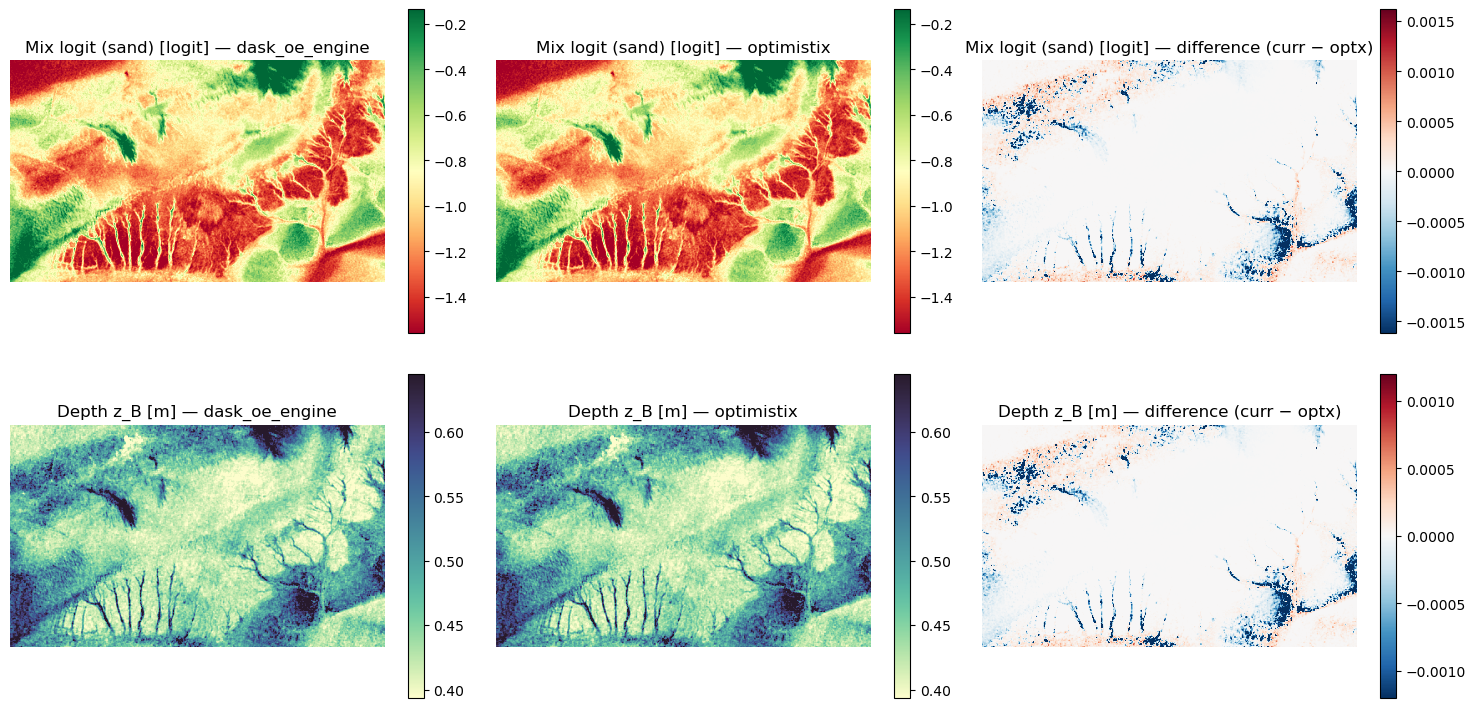

In [13]:
param_labels = {n: PARAM_META[n] for n in setup.fit_names if n in PARAM_META}
n_fit = len(param_labels)

fig, axes = plt.subplots(n_fit, 3, figsize=(15, 4 * n_fit))
axes = np.atleast_2d(axes)

for row, (param, (label, unit, cmap)) in enumerate(param_labels.items()):
    i = setup.fit_names.index(param)
    curr  = results_curr['x_hat'][..., i]
    optx_ = x_hat_optx_phys[..., i]
    diff  = curr - optx_

    vmin, vmax = np.nanpercentile(curr, [2, 98])

    im0 = axes[row, 0].imshow(curr,  vmin=vmin, vmax=vmax, cmap=cmap, origin='upper')
    im1 = axes[row, 1].imshow(optx_, vmin=vmin, vmax=vmax, cmap=cmap, origin='upper')
    im2 = axes[row, 2].imshow(diff,  cmap='RdBu_r',
                               vmin=-np.nanpercentile(np.abs(diff), 98),
                               vmax= np.nanpercentile(np.abs(diff), 98),
                               origin='upper')

    for ax, im, title in zip(axes[row], [im0, im1, im2],
                              ['dask_engine', 'optimistix', 'difference (curr − optx)']):
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'{label} [{unit}] — {title}')
        ax.axis('off')

    print(f'{param}: max |diff| = {np.nanmax(np.abs(diff)):.4g},  '
          f'RMSD = {np.sqrt(np.nanmean(diff**2)):.4g}')

plt.tight_layout()
plt.show()

## Comparison: χ²

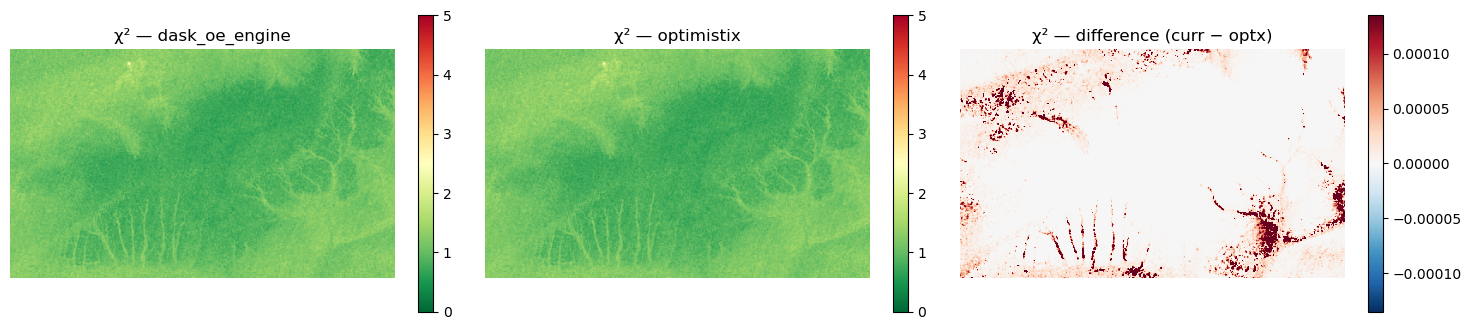

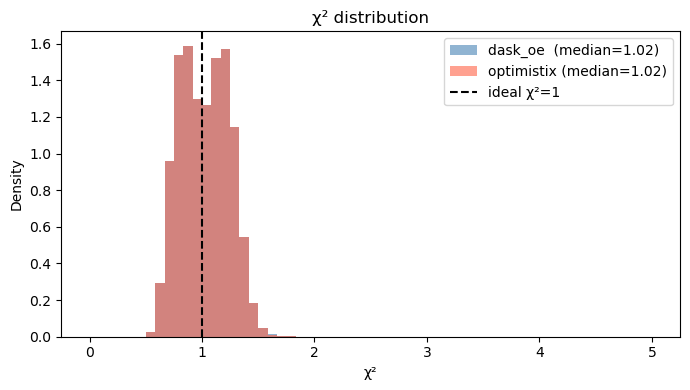

In [14]:
chi2_curr = results_curr['chi2']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in zip(axes,
                            [chi2_curr, chi2_optx, chi2_curr - chi2_optx],
                            ['dask_engine', 'optimistix', 'difference (curr − optx)']):
    if 'diff' in title:
        vabs = np.nanpercentile(np.abs(chi2_curr - chi2_optx), 98)
        im = ax.imshow(data, cmap='RdBu_r', vmin=-vabs, vmax=vabs, origin='upper')
    else:
        im = ax.imshow(data, cmap='RdYlGn_r', vmin=0, vmax=5, origin='upper')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'χ² — {title}')
    ax.axis('off')

plt.tight_layout()
plt.show()

# Histogram overlay
fig, ax = plt.subplots(figsize=(7, 4))
kw = dict(bins=60, range=(0, 5), density=True, alpha=0.6)
ax.hist(chi2_curr.ravel(),  label=f'dask_oe  (median={np.nanmedian(chi2_curr):.2f})',  color='steelblue', **kw)
ax.hist(chi2_optx.ravel(),  label=f'optimistix (median={np.nanmedian(chi2_optx):.2f})', color='tomato',    **kw)
ax.axvline(1.0, color='k', ls='--', lw=1.5, label='ideal χ²=1')
ax.set_xlabel('χ²')
ax.set_ylabel('Density')
ax.set_title('χ² distribution')
ax.legend()
plt.tight_layout()
plt.show()

## Comparison: posterior uncertainty σ

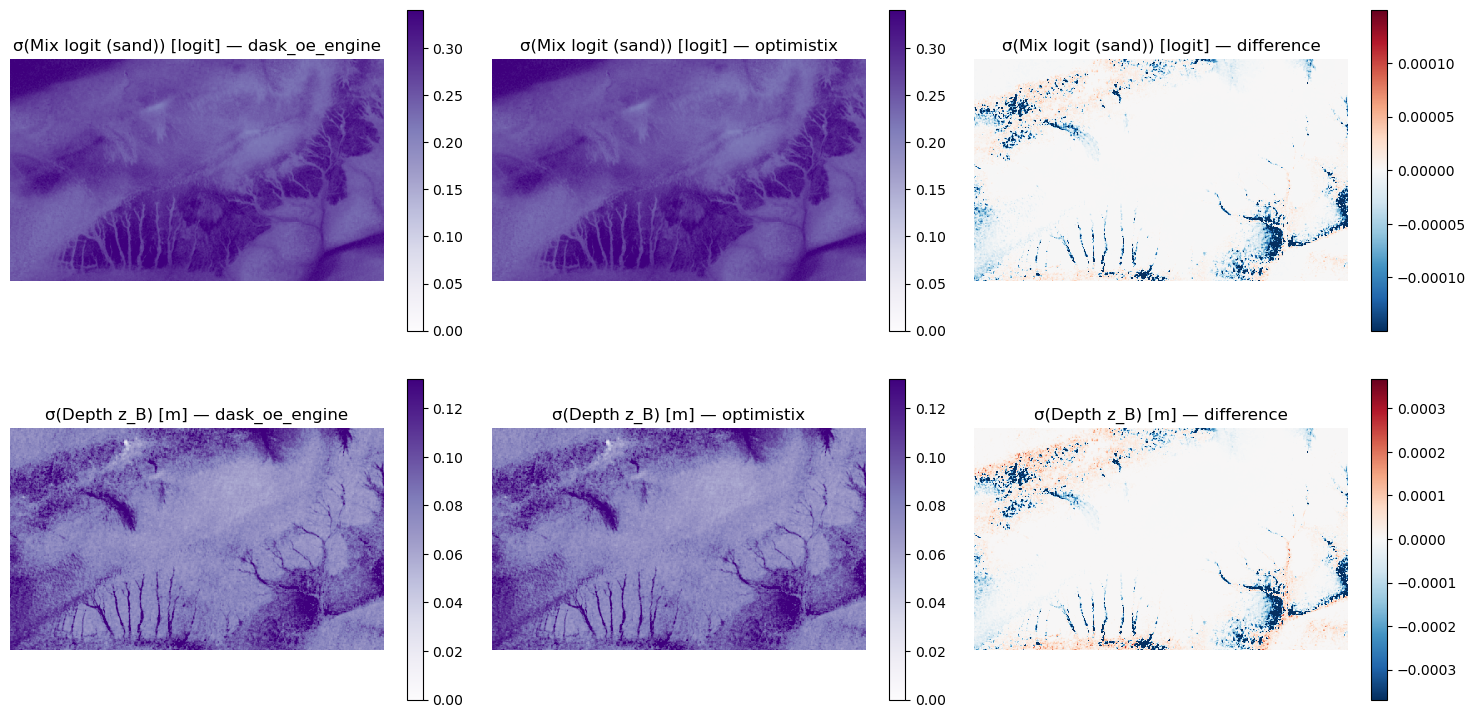

In [15]:
fig, axes = plt.subplots(n_fit, 3, figsize=(15, 4 * n_fit))
axes = np.atleast_2d(axes)

for row, (param, (label, unit, _)) in enumerate(param_labels.items()):
    i = setup.fit_names.index(param)
    curr   = results_curr['sigma'][..., i]
    optx_  = sigma_optx[..., i]
    diff   = curr - optx_

    vmax = np.nanpercentile(curr, 98)

    im0 = axes[row, 0].imshow(curr,  vmin=0, vmax=vmax, cmap='Purples', origin='upper')
    im1 = axes[row, 1].imshow(optx_, vmin=0, vmax=vmax, cmap='Purples', origin='upper')
    im2 = axes[row, 2].imshow(diff,  cmap='RdBu_r',
                               vmin=-np.nanpercentile(np.abs(diff), 98),
                               vmax= np.nanpercentile(np.abs(diff), 98),
                               origin='upper')

    for ax, im, title in zip(axes[row], [im0, im1, im2],
                              ['dask_engine', 'optimistix', 'difference']):
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'σ({label}) [{unit}] — {title}')
        ax.axis('off')

plt.tight_layout()
plt.show()

## Comparison: averaging kernel diagonal A[i,i]

f_mix_0: median A  curr=0.983  optx=0.983
zB: median A  curr=0.933  optx=0.933


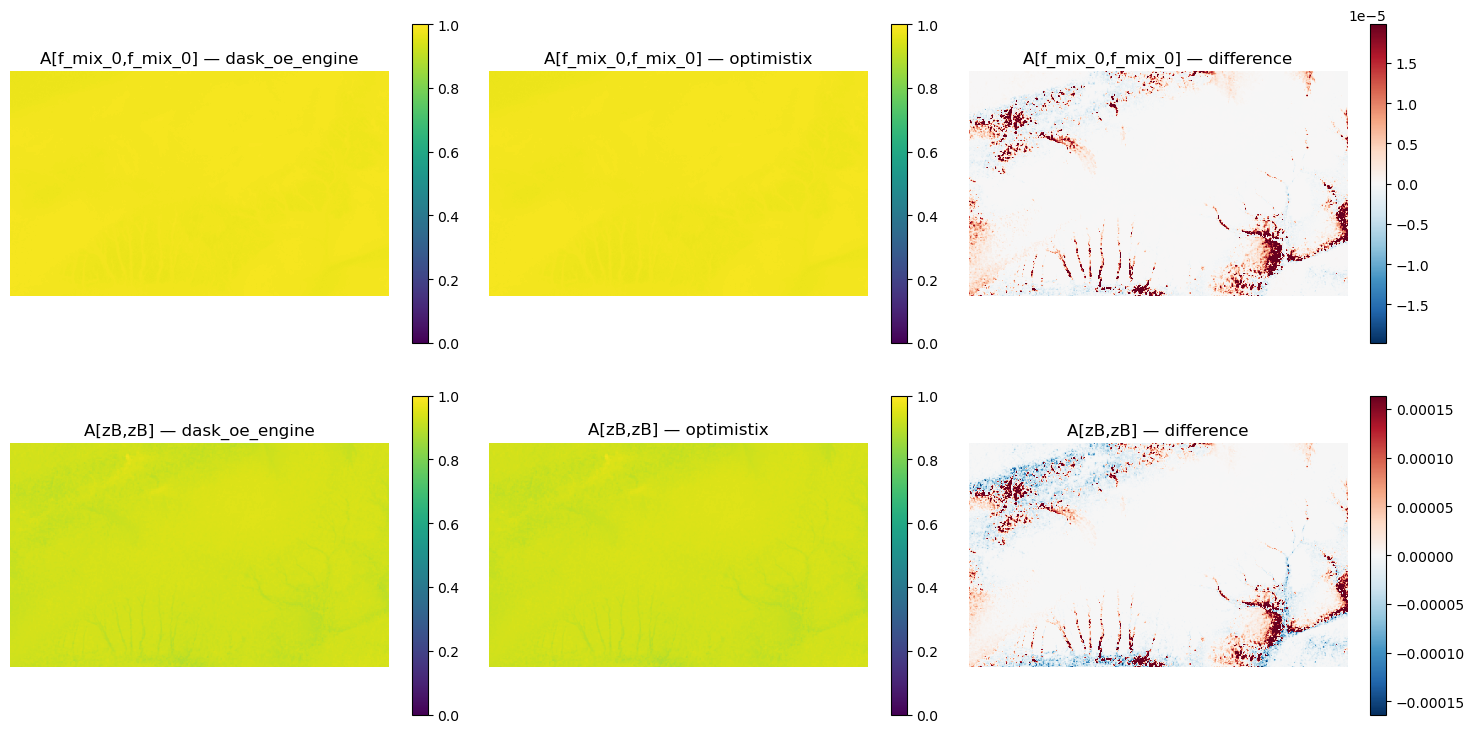

In [16]:
fig, axes = plt.subplots(n_fit, 3, figsize=(15, 4 * n_fit))
axes = np.atleast_2d(axes)

for row, (param, (label, _, __)) in enumerate(param_labels.items()):
    i = setup.fit_names.index(param)
    curr   = results_curr['A_diag'][..., i]
    optx_  = A_diag_optx[..., i]
    diff   = curr - optx_

    im0 = axes[row, 0].imshow(curr,  vmin=0, vmax=1, cmap='viridis', origin='upper')
    im1 = axes[row, 1].imshow(optx_, vmin=0, vmax=1, cmap='viridis', origin='upper')
    im2 = axes[row, 2].imshow(diff,  cmap='RdBu_r',
                               vmin=-np.nanpercentile(np.abs(diff), 98),
                               vmax= np.nanpercentile(np.abs(diff), 98),
                               origin='upper')

    for ax, im, title in zip(axes[row], [im0, im1, im2],
                              ['dask_engine', 'optimistix', 'difference']):
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'A[{param},{param}] — {title}')
        ax.axis('off')

    dfs_curr = np.nanmedian(results_curr['A_diag'][..., i])
    dfs_optx = np.nanmedian(A_diag_optx[..., i])
    print(f'{param}: median A  curr={dfs_curr:.3f}  optx={dfs_optx:.3f}')

plt.tight_layout()
plt.show()

## Numerical agreement summary

In [17]:
w = 30
print(f'\n{"Metric":<{w}s} {"dask_oe":>10s}  {"optx_flat":>10s}  {"optx_dask":>10s}')
print('-' * (w + 36))

def row(label, a, b, c):
    d1, d2 = a - b, a - c
    print(f'{label:<{w}s} {np.nanmedian(a):>10.4f}  {np.nanmedian(b):>10.4f}  {np.nanmedian(c):>10.4f}'
          f'  (RMSD vs dask_oe: {np.sqrt(np.nanmean(d1**2)):.4g} / {np.sqrt(np.nanmean(d2**2)):.4g})')

row('median chi2',
    chi2_curr, chi2_optx, chi2_optx_dask)
row('median H_info (nats)',
    results_curr['H_info'], H_info_optx, H_info_optx_dask)

for param, (label, unit, _) in {n: PARAM_META[n] for n in setup.fit_names if n in PARAM_META}.items():
    i = setup.fit_names.index(param)
    row(f'x_hat {param} ({unit})',
        results_curr['x_hat'][..., i],
        x_hat_optx_phys[..., i],
        x_hat_optx_dask[..., i])

print(f'\n{"Timing":}')
print(f'  dask_engine     first={t_dask_first:.2f}s   hot={t_dask_hot:.2f}s')
print(f'  optx flat          first={t_optx_first:.2f}s   hot={t_optx_hot:.2f}s')
print(f'  invert_image_optx  first={t_optx_dask_first:.2f}s   hot={t_optx_dask_hot:.2f}s')
print()
winner_hot = min([
    ('dask_engine',    t_dask_hot),
    ('optx flat',         t_optx_hot),
    ('invert_image_optx', t_optx_dask_hot),
], key=lambda x: x[1])
print(f'  Hot-run winner: {winner_hot[0]} ({winner_hot[1]:.2f}s)')


Metric                            dask_oe   optx_flat   optx_dask
------------------------------------------------------------------
median chi2                        1.0197      1.0197      1.0197  (RMSD vs dask_oe: 8.413e-05 / 8.413e-05)
median H_info (nats)               3.4795      3.4795      3.4795  (RMSD vs dask_oe: 0.0003998 / 0.0003998)
x_hat f_mix_0 (logit)             -0.9738     -0.9739     -0.9739  (RMSD vs dask_oe: 0.0006956 / 0.0006956)
x_hat zB (m)                       0.4492      0.4492      0.4492  (RMSD vs dask_oe: 0.0005458 / 0.0005458)

Timing
  dask_engine     first=99.00s   hot=36.32s
  optx flat          first=37.78s   hot=32.32s
  invert_image_optx  first=41.14s   hot=28.94s

  Hot-run winner: invert_image_optx (28.94s)
